RMSE (Polynomial): 9.965326786519533
RMSE (Linear): 10.045790874078271


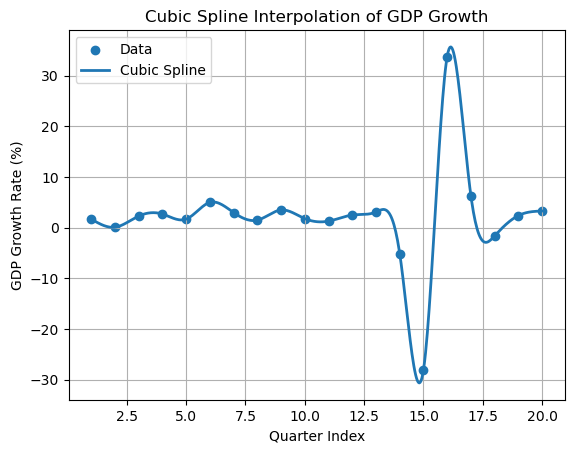

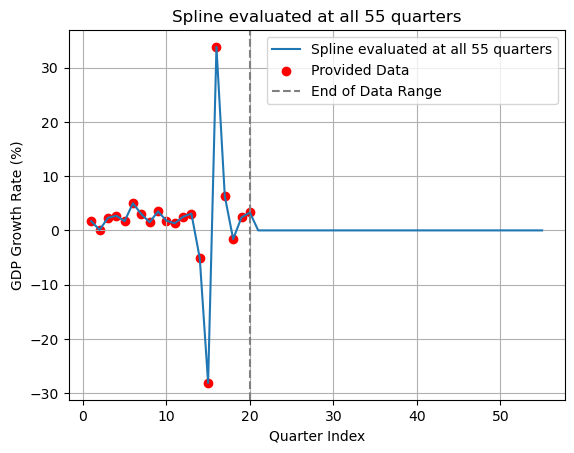

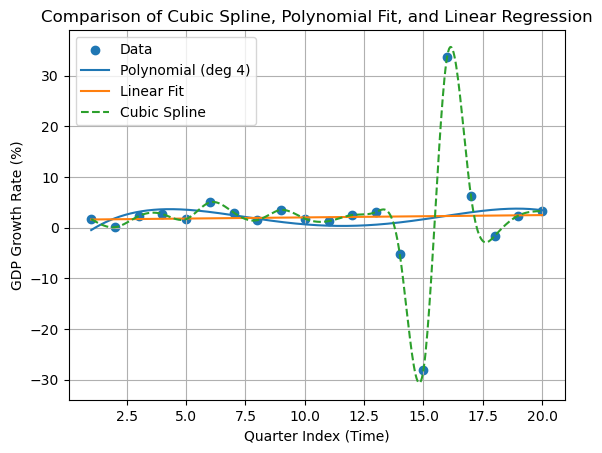

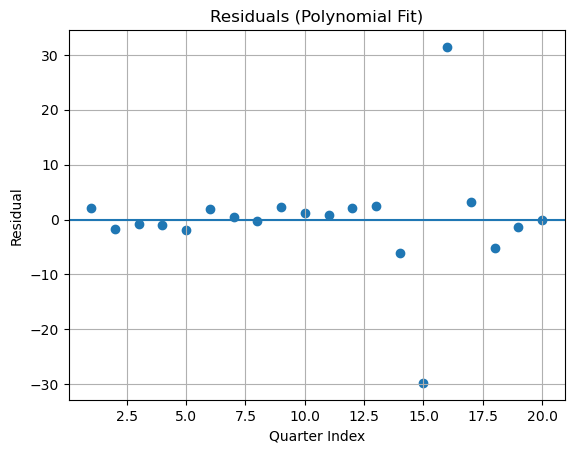

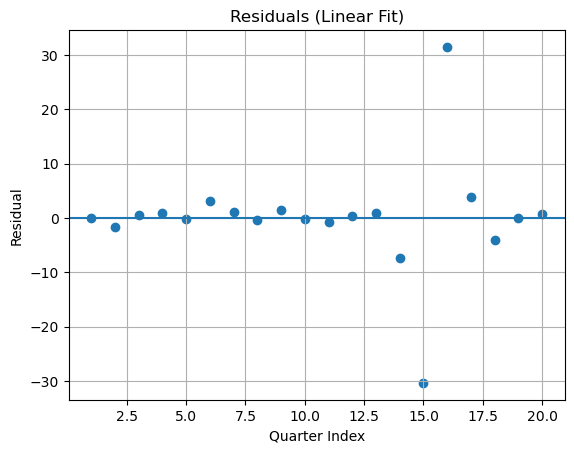

In [11]:
import numpy as np
import matplotlib.pyplot as plt

# Data

x = np.arange(1, 21)
y = np.array([1.7,0.1,2.3,2.7,1.7,5.0,3.0,1.5,3.5,1.8,
              1.3,2.5,3.1,-5.1,-28.1,33.8,6.3,-1.6,2.4,3.3])


# Least Squares Linear Regression

def linear_regression(x, y):
    A = np.vstack([x, np.ones(len(x))]).T
    ATA = A.T @ A
    ATy = A.T @ y
    return np.linalg.solve(ATA, ATy)


# Polynomial Fit (degree 4)

def polynomial_fit(x, y, degree):
    A = np.vander(x, degree+1, increasing=False)
    ATA = A.T @ A
    ATy = A.T @ y
    return np.linalg.solve(ATA, ATy)


# Cubic Spline (Natural)

def cubic_spline(x, y):
    n = len(x)
    h = np.diff(x)
    A = np.zeros((n-2, n-2))
    b = np.zeros(n-2)

    for i in range(n-2):
        if i > 0:
            A[i, i-1] = h[i]
        A[i, i] = 2*(h[i] + h[i+1])
        if i < n-3:
            A[i, i+1] = h[i+1]
        b[i] = 6*((y[i+2]-y[i+1])/h[i+1] - (y[i+1]-y[i])/h[i])

    M = np.zeros(n)
    M[1:-1] = np.linalg.solve(A, b)
    return M


# Evaluate Spline

def evaluate_spline(x, y, M, x_eval):
    n = len(x)
    y_eval = np.zeros_like(x_eval, dtype=float)

    for j, xv in enumerate(x_eval):
        for i in range(n-1):
            if x[i] <= xv <= x[i+1]:
                h = x[i+1] - x[i]

                term1 = M[i] * (x[i+1] - xv)**3 / (6*h)
                term2 = M[i+1] * (xv - x[i])**3 / (6*h)
                term3 = (y[i] - M[i]*h**2/6) * (x[i+1] - xv) / h
                term4 = (y[i+1] - M[i+1]*h**2/6) * (xv - x[i]) / h

                y_eval[j] = term1 + term2 + term3 + term4
                break

    return y_eval


# RMSE Function

def rmse(y_true, y_pred):
    return np.sqrt(np.mean((y_true - y_pred)**2))


# Compute Models

lin = linear_regression(x, y)
poly = polynomial_fit(x, y, 4)
spline_M = cubic_spline(x, y)


# Interpolation region (for plotting)
x_dense = np.linspace(1, 20, 500)
y_spline_dense = evaluate_spline(x, y, spline_M, x_dense)

# Full evaluation (for requirement)
x_full = np.arange(1, 56)
y_spline_full = evaluate_spline(x, y, spline_M, x_full)

# Linear
lin_vals = lin[0]*x_dense + lin[1]

# Polynomial
poly_vals = np.polyval(poly, x_dense)



# Residuals

y_poly_data = np.polyval(poly, x)
residuals_poly = y - y_poly_data

y_lin_data = lin[0]*x + lin[1]
residuals_lin = y - y_lin_data


# RMSE

rmse_poly = rmse(y, y_poly_data)
rmse_lin = rmse(y, y_lin_data)

print("RMSE (Polynomial):", rmse_poly)
print("RMSE (Linear):", rmse_lin)

# Plot Cubic Spline 

plt.figure()
plt.scatter(x, y, label='Data')
plt.plot(x_dense, y_spline_dense, label='Cubic Spline', linewidth=2)

plt.title('Cubic Spline Interpolation of GDP Growth')
plt.xlabel('Quarter Index')
plt.ylabel('GDP Growth Rate (%)')
plt.legend()
plt.grid(True)
plt.show()

plt.figure()
plt.plot(x_full, y_spline_full, label='Spline evaluated at all 55 quarters')
plt.scatter(x, y, color='red', label='Provided Data')
plt.title('Spline evaluated at all 55 quarters')
plt.xlabel('Quarter Index')
plt.ylabel('GDP Growth Rate (%)')
plt.axvline(x=20, linestyle='--', color='gray', label='End of Data Range')
plt.legend()
plt.grid(True)
plt.show()

# Plot Comparison

plt.figure()
plt.scatter(x, y, label='Data')
plt.plot(x_dense, poly_vals, label='Polynomial (deg 4)')
plt.plot(x_dense, lin_vals, label='Linear Fit')
plt.plot(x_dense, y_spline_dense, label='Cubic Spline', linestyle='--')

plt.title('Comparison of Cubic Spline, Polynomial Fit, and Linear Regression')
plt.xlabel('Quarter Index (Time)')
plt.ylabel('GDP Growth Rate (%)')
plt.legend()
plt.grid(True)
plt.show()

# Plot Residuals (Polynomial)

plt.figure()
plt.scatter(x, residuals_poly)
plt.axhline(0)
plt.title('Residuals (Polynomial Fit)')
plt.xlabel('Quarter Index')
plt.ylabel('Residual')
plt.grid(True)
plt.show()


# Plot Residuals (Linear)

plt.figure()
plt.scatter(x, residuals_lin)
plt.axhline(0)
plt.title('Residuals (Linear Fit)')
plt.xlabel('Quarter Index')
plt.ylabel('Residual')
plt.grid(True)
plt.show()